In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
# import wordcloud import wordcloud stopwords imagecolorgenerator
# import warnings 
# warnings.filterwarnings("ignore")

In [2]:
data=pd.read_csv("amazon_prime_titles.csv")
data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama",A small fishing village must procure a local d...
1,s2,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International",A Metro Family decides to fight a Cyber Crimin...
2,s3,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense",After a man discovers his wife is cheating on ...
3,s4,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary,"Pink breaks the mold once again, bringing her ..."
4,s5,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy",Teenage Matt Banting wants to work with a famo...


In [3]:
# data.drop(["show_id"],axis=1,inplace=True)
# data.drop(["description"],axis=1,inplace=True)
# data.head()

In [4]:
data.drop(columns=["show_id"],inplace=True)
data.drop(columns=["description"],inplace=True)
data.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,"March 30, 2021",2014,NaN,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,"March 30, 2021",2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,"March 30, 2021",2017,NaN,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,"March 30, 2021",2014,NaN,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,"March 30, 2021",1989,NaN,45 min,"Drama, Fantasy"


In [5]:
data.duplicated().sum()

np.int64(0)

In [6]:
data.shape

(9668, 10)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          9668 non-null   object
 1   title         9668 non-null   object
 2   director      7585 non-null   object
 3   cast          8435 non-null   object
 4   country       672 non-null    object
 5   date_added    155 non-null    object
 6   release_year  9668 non-null   int64 
 7   rating        9331 non-null   object
 8   duration      9668 non-null   object
 9   listed_in     9668 non-null   object
dtypes: int64(1), object(9)
memory usage: 755.4+ KB


In [8]:
data.isnull().sum()

type               0
title              0
director        2083
cast            1233
country         8996
date_added      9513
release_year       0
rating           337
duration           0
listed_in          0
dtype: int64

In [9]:
data["director"].fillna("Unavailable",inplace=True)
data["cast"].fillna("Unavailable",inplace=True)
data["country"].fillna("Unavailable",inplace=True)
# ffill means forward fill if 1 place is empty and next one is full then 1st one is filled as same as next one 
data["date_added"]=data["date_added"].ffill()
data["rating"]=data["rating"].fillna(data["rating"].mode()[0])
data.isnull().sum()

C:\Users\hp\AppData\Local\Temp\ipykernel_1468\2464969175.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["director"].fillna("Unavailable",inplace=True)
C:\Users\hp\AppData\Local\Temp\ipykernel_1468\2464969175.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example,

type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
dtype: int64

In [10]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          9668 non-null   object
 1   title         9668 non-null   object
 2   director      9668 non-null   object
 3   cast          9668 non-null   object
 4   country       9668 non-null   object
 5   date_added    9668 non-null   object
 6   release_year  9668 non-null   int64 
 7   rating        9668 non-null   object
 8   duration      9668 non-null   object
 9   listed_in     9668 non-null   object
dtypes: int64(1), object(9)
memory usage: 755.4+ KB


In [11]:
data["date_added"]=pd.to_datetime(data["date_added"])
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9668 entries, 0 to 9667
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   type          9668 non-null   object        
 1   title         9668 non-null   object        
 2   director      9668 non-null   object        
 3   cast          9668 non-null   object        
 4   country       9668 non-null   object        
 5   date_added    9668 non-null   datetime64[ns]
 6   release_year  9668 non-null   int64         
 7   rating        9668 non-null   object        
 8   duration      9668 non-null   object        
 9   listed_in     9668 non-null   object        
dtypes: datetime64[ns](1), int64(1), object(8)
memory usage: 755.4+ KB


In [12]:
data.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy"


In [13]:
# top 10 directors with most directed movies
filtered_directors=data[data["director"] != "Unavailable"]
top_directors=filtered_directors["director"].value_counts()[:10]

In [14]:
top_directors

director
Mark Knight              113
Cannis Holder             61
Moonbug Entertainment     37
Jay Chapman               34
Arthur van Merwijk        30
Manny Rodriguez           22
John English              20
1                         16
Brian Volk-Weiss          15
Baeble Music              14
Name: count, dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_1468\3307882384.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_directors.values,y=top_directors.index,palette="plasma")


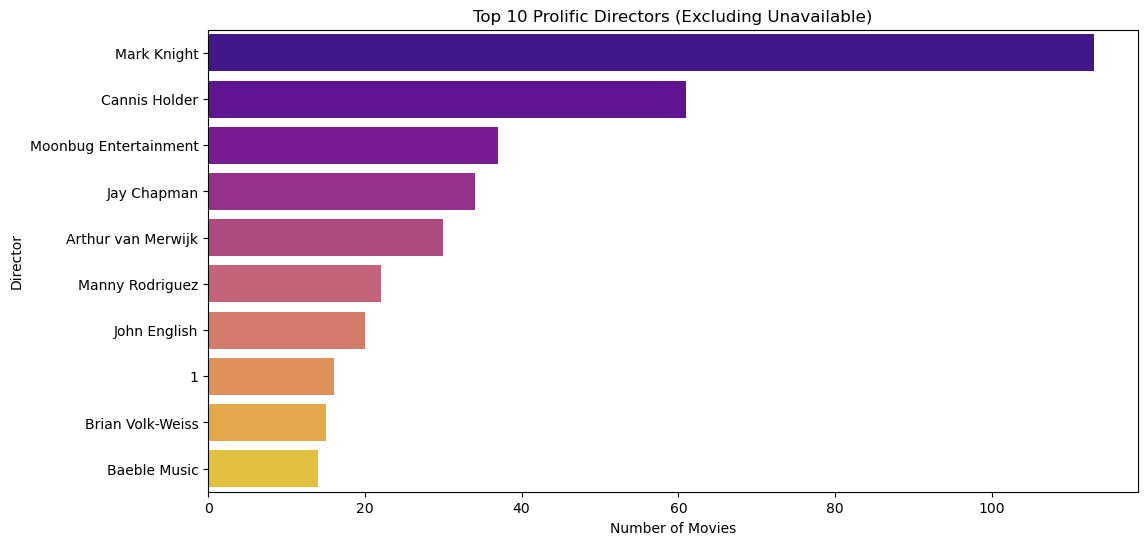

In [15]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_directors.values,y=top_directors.index,palette="plasma")
plt.title("Top 10 Prolific Directors (Excluding Unavailable)")
plt.xlabel("Number of Movies")
plt.ylabel("Director")
plt.show()

In [16]:
# top 10 directors with most actors
filtered_actors=data[data["cast"] != "Unavailable"]
top_actors=filtered_actors["cast"].value_counts().head(10)
top_actors

cast
Maggie Binkley                      56
1                                   34
Anne-Marie Newland                  24
Cassandra Peterson                  21
Grace Tamayo, Erin Webbs            17
Gene Autry, Champion, Gail Davis    12
Stevin John                         11
LB, Aaron Michael                    9
Gallagher                            9
Eddie Izzard                         9
Name: count, dtype: int64

C:\Users\hp\AppData\Local\Temp\ipykernel_1468\1728421224.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_actors.values,y=top_actors.index,palette="husl")


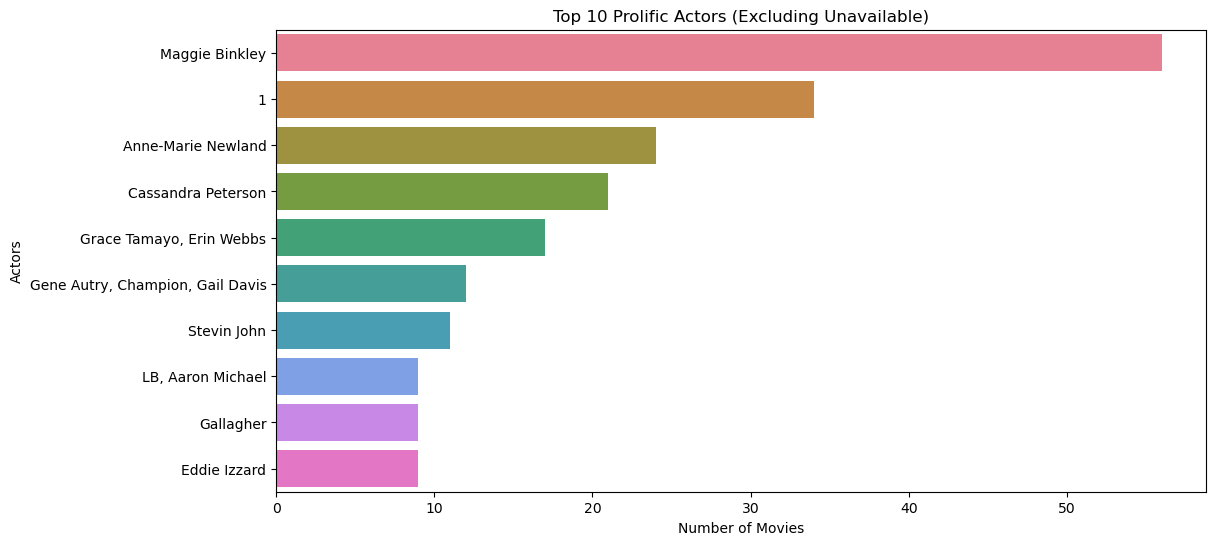

In [17]:
plt.figure(figsize=(12,6))
sns.barplot(x=top_actors.values,y=top_actors.index,palette="husl")
plt.title("Top 10 Prolific Actors (Excluding Unavailable)")
plt.xlabel("Number of Movies")
plt.ylabel("Actors")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_1468\326007631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=data,x="type" ,palette="viridis")


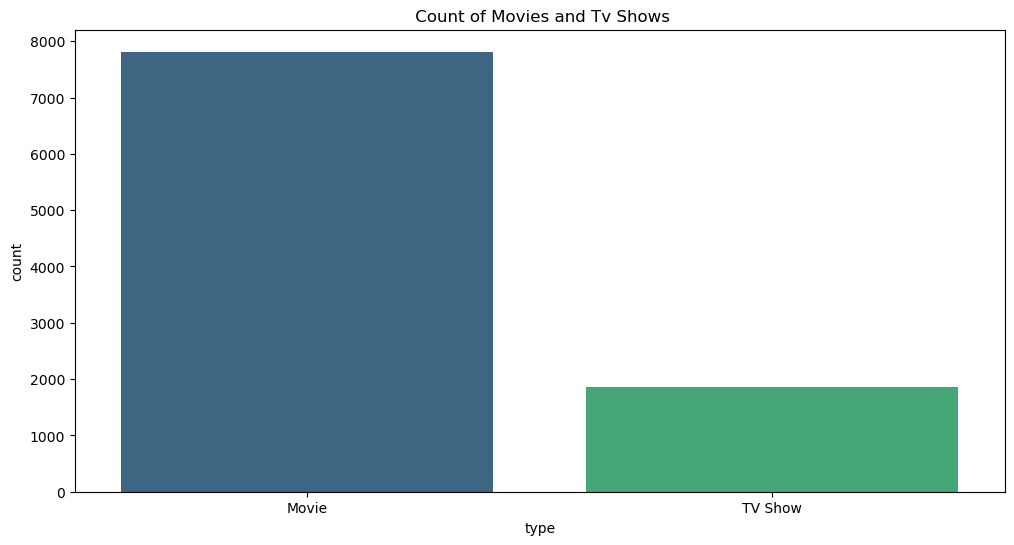

In [18]:
# count of each content type(movies and tv shows)
plt.figure(figsize=(12,6))
sns.countplot(data=data,x="type" ,palette="viridis")
plt.title(" Count of Movies and Tv Shows")
plt.show()

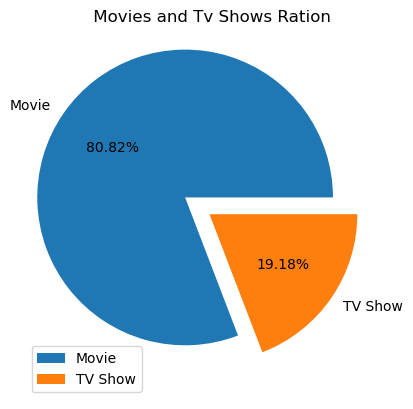

In [19]:
plt.pie(
    data["type"].value_counts(),labels=data["type"].value_counts().index,autopct="%1.2f%%",explode=[0.2,0]
)
plt.title(" Movies and Tv Shows Ration")
plt.legend()
plt.show()

In [20]:
data["rating"].unique()

array(['13+', 'ALL', '18+', 'R', 'TV-Y', 'TV-Y7', 'NR', '16+', 'TV-PG',
       '7+', 'TV-14', 'TV-NR', 'TV-G', 'PG-13', 'TV-MA', 'G', 'PG',
       'NC-17', 'UNRATED', '16', 'AGES_16_', 'AGES_18_', 'ALL_AGES',
       'NOT_RATE'], dtype=object)

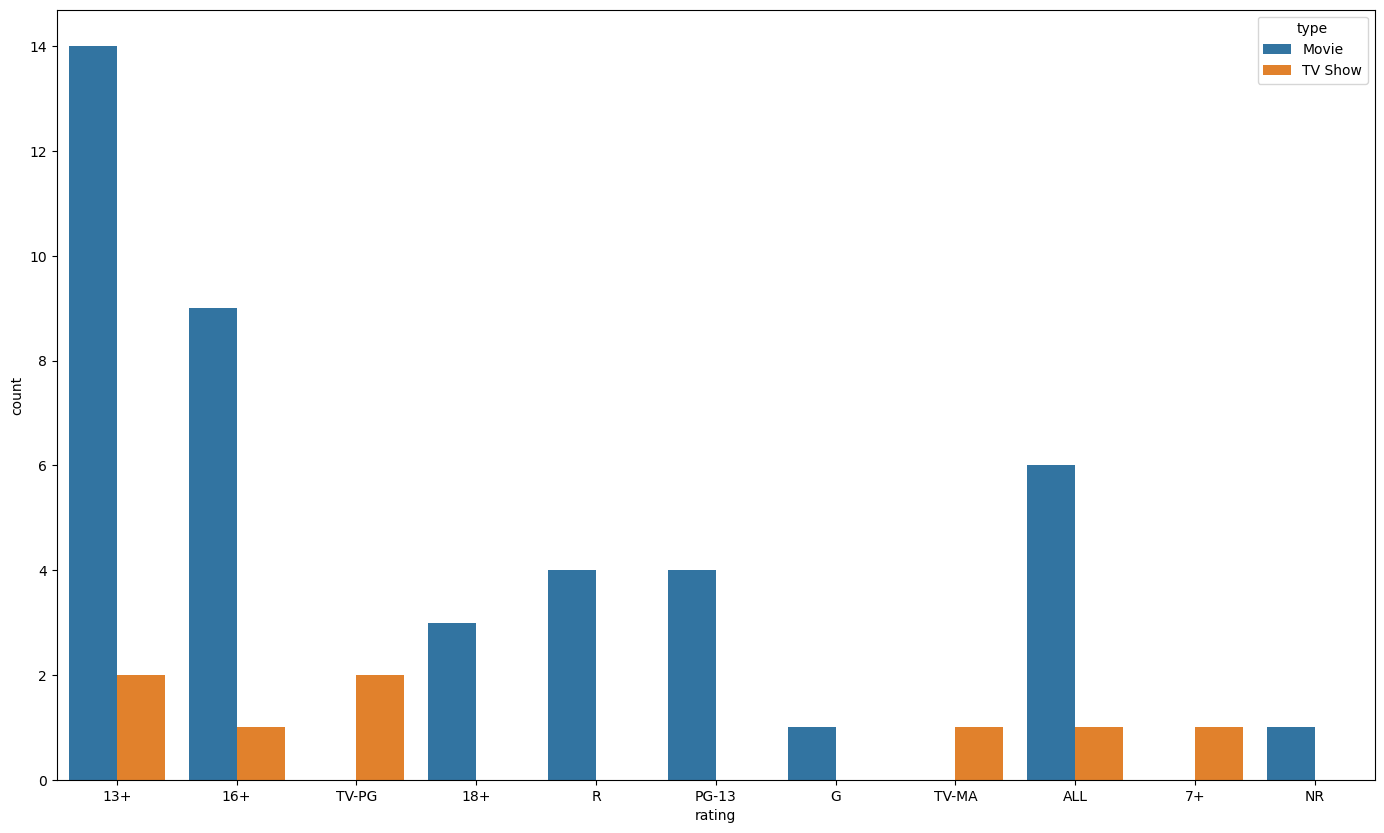

In [21]:
plt.figure(figsize=(17,10))
sns.countplot(x="rating",data=data.sample(50),hue="type")
plt.show()

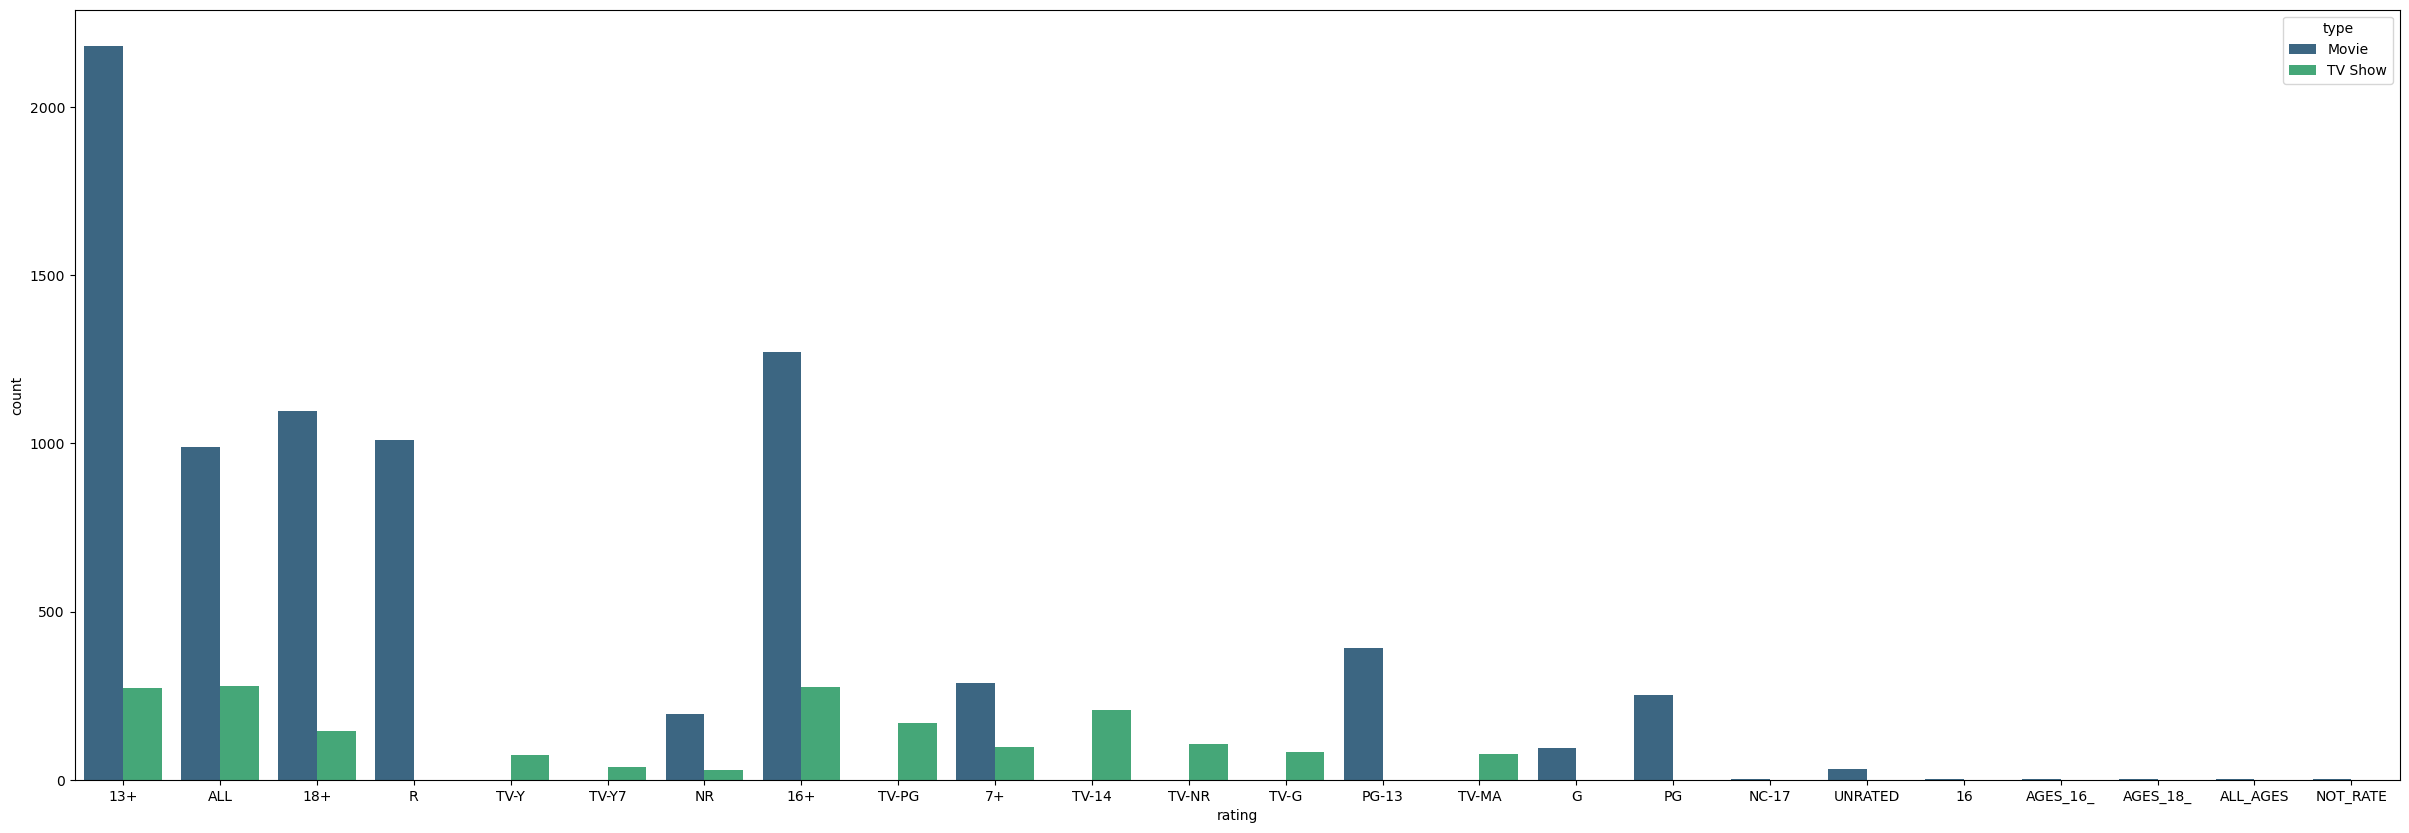

In [22]:
plt.figure(figsize=(30,10))
sns.countplot(x=data["rating"],data=data,hue="type",palette="viridis")
plt.show()

In [23]:
# calculating the number of titles per country
filtered_country=data[data["country"] != "Unavailable"]
country_counts=filtered_country["country"].value_counts()
country_counts

country
United States                                               253
India                                                       229
United Kingdom                                               28
Canada                                                       16
United Kingdom, United States                                12
                                                           ... 
United States, Mexico                                         1
United States, Germany, Japan, United Kingdom, Hong Kong      1
Italy, Canada                                                 1
France, Belgium                                               1
Italy, Spain                                                  1
Name: count, Length: 86, dtype: int64

In [24]:
# getting the top 3 countries
top_countries=country_counts.nlargest(3).index
top_countries

Index(['United States', 'India', 'United Kingdom'], dtype='object', name='country')

In [25]:
# filtering the dataFrame to include only the top 3 countries
df_top_countries=filtered_country[filtered_country["country"].isin(top_countries)]
df_top_countries

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy"
5,Movie,Living With Dinosaurs,Paul Weiland,"Gregory Chisholm, Juliet Stevenson, Brian Hens...",United Kingdom,2021-03-30,1989,13+,52 min,"Fantasy, Kids"
...,...,...,...,...,...,...,...,...,...,...
9604,Movie,Bride Wars,Gary Winick,"Kate Hudson, Anne Hathaway, Kristen Johnston, ...",United States,2021-10-08,2009,PG,89 min,Comedy
9614,Movie,What Happens in Vegas,Tom Vaughan,"Cameron Diaz, Ashton Kutcher, Rob Corddry, ...",United States,2021-10-08,2008,PG-13,99 min,Comedy
9641,Movie,Marley & Me,David Frankel,"Owen Wilson, Jennifer Aniston",United States,2021-10-10,2008,PG,116 min,"Comedy, Drama, Kids"
9643,Movie,Love & Other Drugs,Edward Zwick,"K K, Jake Gyllenhaal, Anne Hathaway, Oliver Pl...",United States,2021-10-10,2010,R,112 min,"Comedy, Drama"


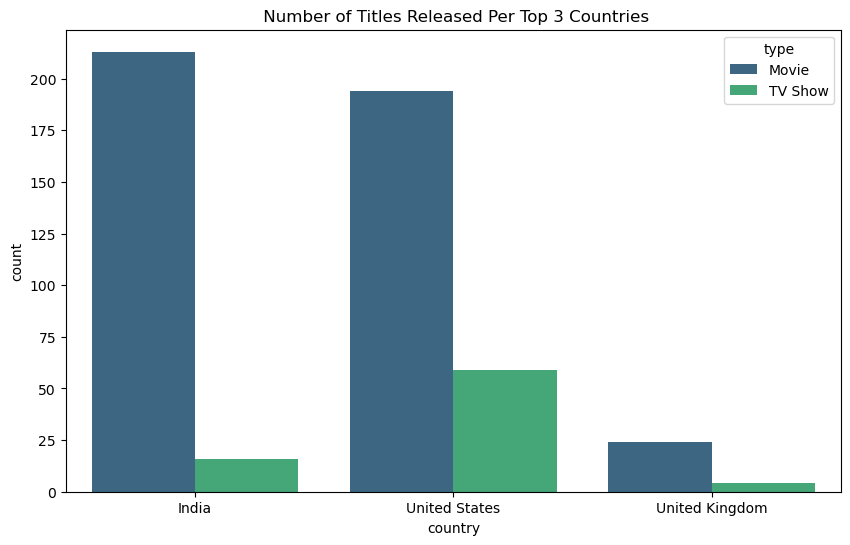

In [26]:
#plotting the number of titles released per top 3 countries
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_countries,x="country",hue="type",palette="viridis")
plt.title(" Number of Titles Released Per Top 3 Countries")
plt.show()

In [27]:
# calculating the number of release year
years_counts=data["release_year"].value_counts()
years_counts

release_year
2021    1442
2020     962
2019     929
2018     623
2017     562
        ... 
1926       2
1922       2
1924       1
1923       1
1927       1
Name: count, Length: 100, dtype: int64

In [28]:
years_counts.index

Index([2021, 2020, 2019, 2018, 2017, 2016, 2014, 2015, 2013, 2012, 2011, 2010,
       2007, 2008, 2009, 2006, 2005, 2004, 2002, 2001, 2000, 2003, 1995, 1999,
       1994, 1996, 1998, 1997, 1993, 1992, 1989, 1991, 1988, 1986, 1990, 1987,
       1936, 1985, 1984, 1975, 1970, 1980, 1974, 1937, 1978, 1941, 1947, 1981,
       1939, 1953, 1950, 1946, 1943, 1972, 1963, 1968, 1959, 1951, 1956, 1983,
       1982, 1973, 1967, 1942, 1979, 1969, 1952, 1940, 1971, 1935, 1954, 1938,
       1948, 1958, 1945, 1949, 1977, 1964, 1944, 1934, 1962, 1976, 1960, 1961,
       1966, 1955, 1965, 1932, 1925, 1930, 1957, 1933, 1929, 1920, 1931, 1926,
       1922, 1924, 1923, 1927],
      dtype='int64', name='release_year')

In [29]:
# getting thw top 10 release year
top_years=years_counts.nlargest(10).index
top_years

Index([2021, 2020, 2019, 2018, 2017, 2016, 2014, 2015, 2013, 2012], dtype='int64', name='release_year')

In [30]:
# filtering the dataframe to include only the top 10 years
df_top_years=data[data["release_year"].isin(top_years)]
df_top_years

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary
6,Movie,Hired Gun,Fran Strine,"Alice Cooper, Liberty DeVitto, Ray Parker Jr.,...",United States,2021-03-30,2017,13+,98 min,"Documentary, Special Interest"
...,...,...,...,...,...,...,...,...,...,...
9657,Movie,A Place at the Table,"Kristi Jacobson, Lori Silverbush","Jeff Bridges, Tom Colicchio",Unavailable,2021-10-10,2013,PG,84 min,"Documentary, Special Interest"
9660,Movie,The Man in the Hat,"John-Paul Davidson, Stephen Warbeck","Ciaran Hinds, Stephen Dillane, Maïwenn",Unavailable,2021-10-10,2021,13+,96 min,Comedy
9662,Movie,River,Emily Skye,"Mary Cameron Rogers, Alexandra Rose, Rob Marsh...",Unavailable,2021-10-10,2021,16+,93 min,"Drama, Science Fiction, Suspense"
9664,TV Show,Planet Patrol,Unavailable,"DICK VOSBURGH, RONNIE STEVENS, LIBBY MORRIS, M...",Unavailable,2021-10-10,2018,13+,4 Seasons,TV Shows


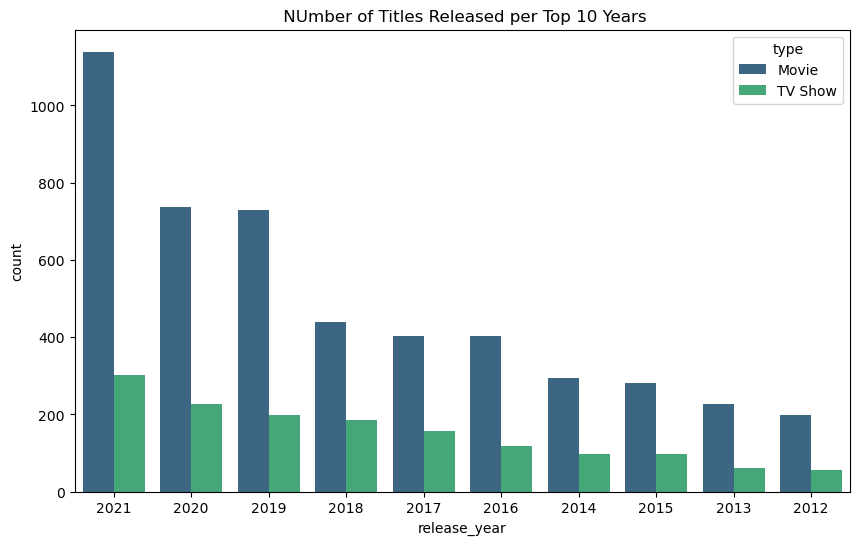

In [31]:
# plotting the number of titles released per top 10 years
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_years,x="release_year",hue="type",palette="viridis",order=top_years)
plt.title(" NUmber of Titles Released per Top 10 Years")
plt.show()

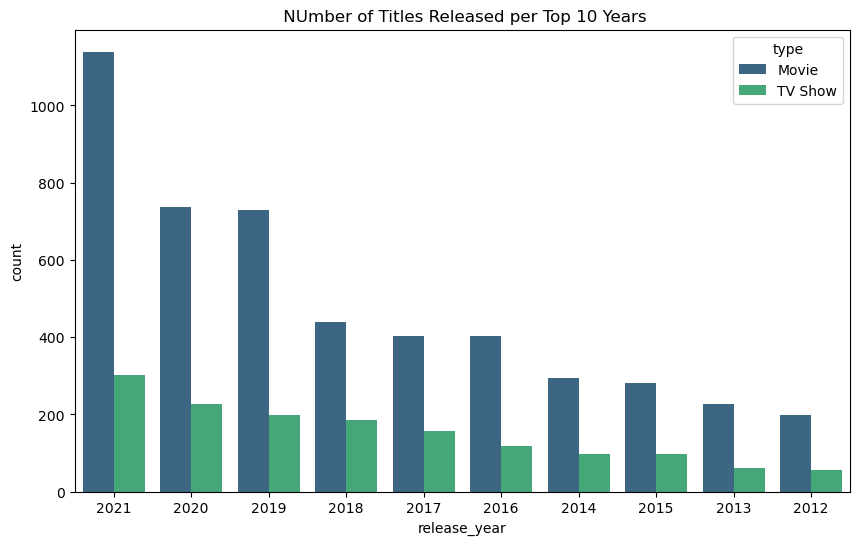

In [32]:
# calculating the number of release year
years_counts=data["release_year"].value_counts()

# getting thw top 10 release year
top_years=years_counts.nlargest(10).index

# filtering the dataframe to include only the top 10 years
df_top_years=data[data["release_year"].isin(top_years)]

# plotting the number of titles released per top 10 years
plt.figure(figsize=(10,6))
sns.countplot(data=df_top_years,x="release_year",hue="type",palette="viridis",order=top_years)
plt.title(" NUmber of Titles Released per Top 10 Years")
plt.show()

In [33]:
data.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama"
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International"
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense"
3,Movie,Pink: Staying True,Sonia Anderson,"Interviews with: Pink, Adele, Beyoncé, Britney...",United States,2021-03-30,2014,13+,69 min,Documentary
4,Movie,Monster Maker,Giles Foster,"Harry Dean Stanton, Kieran O'Brien, George Cos...",United Kingdom,2021-03-30,1989,13+,45 min,"Drama, Fantasy"


In [34]:
# Distribution of genres
# splitting the genres
data["Genres"]=data["listed_in"].apply(lambda x: x.split(", "))
data["Genres"]

0                 [Comedy, Drama]
1          [Drama, International]
2       [Action, Drama, Suspense]
3                   [Documentary]
4                [Drama, Fantasy]
                  ...            
9663                     [Comedy]
9664                   [TV Shows]
9665                     [Action]
9666              [Drama, Sports]
9667    [Action, Drama, Suspense]
Name: Genres, Length: 9668, dtype: object

In [35]:
# exploding the genres into seprate rows
genres_exploded=data.explode("Genres")
genres_exploded

,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,Genres
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama",Comedy
0,Movie,The Grand Seduction,Don McKellar,"Brendan Gleeson, Taylor Kitsch, Gordon Pinsent",Canada,2021-03-30,2014,13+,113 min,"Comedy, Drama",Drama
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",Drama
1,Movie,Take Care Good Night,Girish Joshi,"Mahesh Manjrekar, Abhay Mahajan, Sachin Khedekar",India,2021-03-30,2018,13+,110 min,"Drama, International",International
2,Movie,Secrets of Deception,Josh Webber,"Tom Sizemore, Lorenzo Lamas, Robert LaSardo, R...",United States,2021-03-30,2017,13+,74 min,"Action, Drama, Suspense",Action
...,...,...,...,...,...,...,...,...,...,...,...
9666,TV Show,Maradona: Blessed Dream,Unavailable,"Esteban Recagno, Ezequiel Stremiz, Luciano Vit...",Unavailable,2021-10-10,2021,TV-MA,1 Season,"Drama, Sports",Drama
9666,TV Show,Maradona: Blessed Dream,Unavailable,"Esteban Recagno, Ezequiel Stremiz, Luciano Vit...",Unavailable,2021-10-10,2021,TV-MA,1 Season,"Drama, Sports",Sports
9667,Movie,Harry Brown,Daniel Barber,"Michael Caine, Emily Mortimer, Joseph Gilgun, ...",Unavailable,2021-10-10,2010,R,103 min,"Action, Drama, Suspense",Action
9667,Movie,Harry Brown,Daniel Barber,"Michael Caine, Emily Mortimer, Joseph Gilgun, ...",Unavailable,2021-10-10,2010,R,103 min,"Action, Drama, Suspense",Drama


C:\Users\hp\AppData\Local\Temp\ipykernel_1468\1705113940.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=genres_exploded,y="Genres",order=x,palette="viridis")


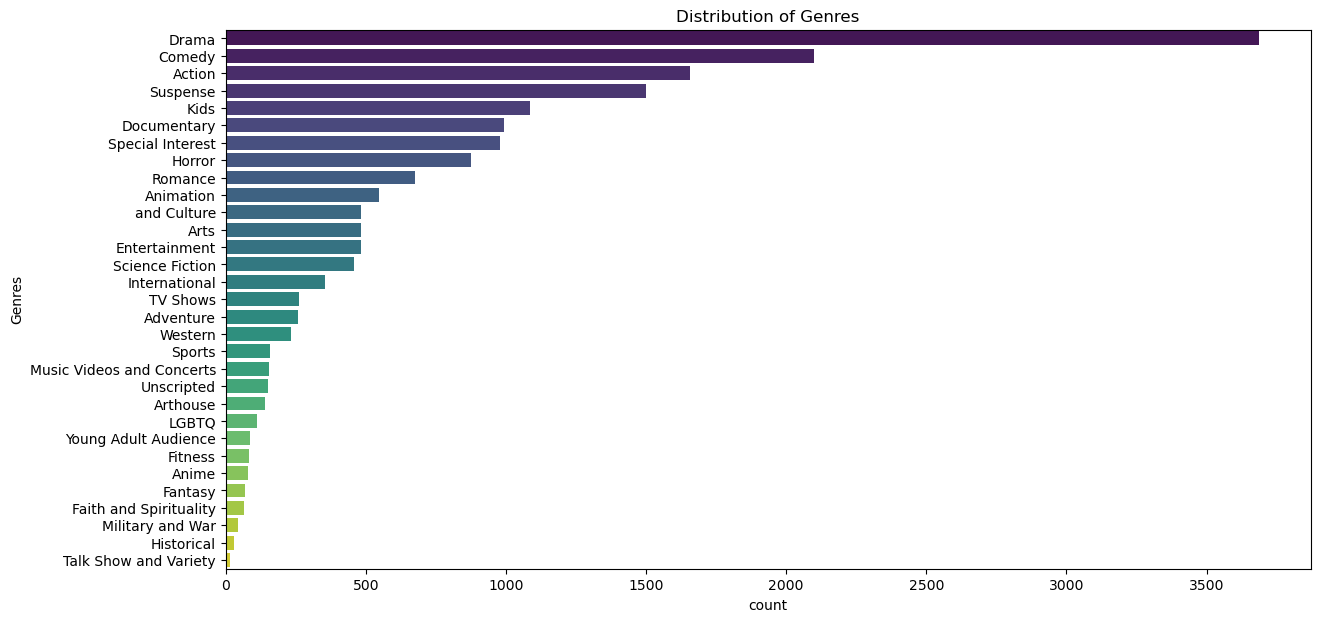

In [36]:
x=genres_exploded["Genres"].value_counts().index
plt.figure(figsize=(14,7))
sns.countplot(data=genres_exploded,y="Genres",order=x,palette="viridis")
plt.title("Distribution of Genres")
plt.show()

In [37]:
# filter data for movies and ttv show seprately
df_movies=data[data["type"]== "Movie"].copy()
df_tv_shows=data[data["type"]== "TV Show"].copy()

In [38]:
# extract numeric duration for movies
df_movies["duration_num"]=df_movies["duration"].str.extract('(\d+)',expand=False).astype(float)

In [39]:
#extra# extract numeric duration for tv shows
df_tv_shows["duration_num"]=df_tv_shows["duration"].str.extract('(\d+)',expand=False).astype(float)

C:\Users\hp\AppData\Local\Temp\ipykernel_1468\948600967.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_movies.sort_values(by="duration_num",


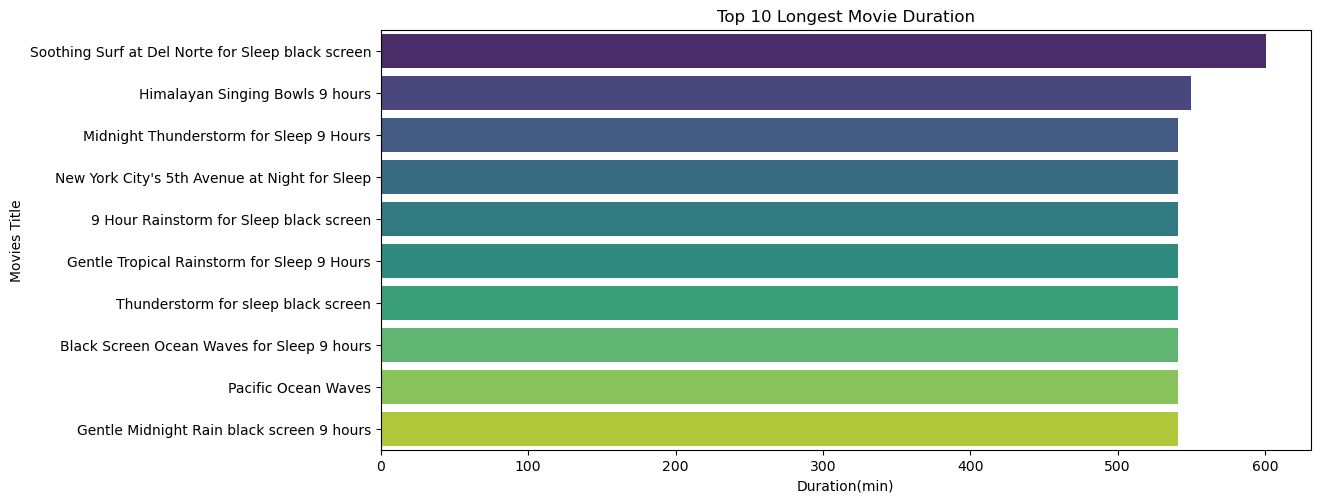

In [40]:
#plotting
plt.figure(figsize=(12,12))
#subplot 1: Top 10 longest Movies Duration
plt.subplot(2, 1, 1)
sns.barplot(data=df_movies.sort_values(by="duration_num",
                                       ascending =False).head(10),y="title",x="duration_num",palette="viridis")
plt.title("Top 10 Longest Movie Duration")
plt.xlabel("Duration(min)")
plt.ylabel("Movies Title")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_1468\3246620045.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tv_shows.sort_values(by="duration_num",


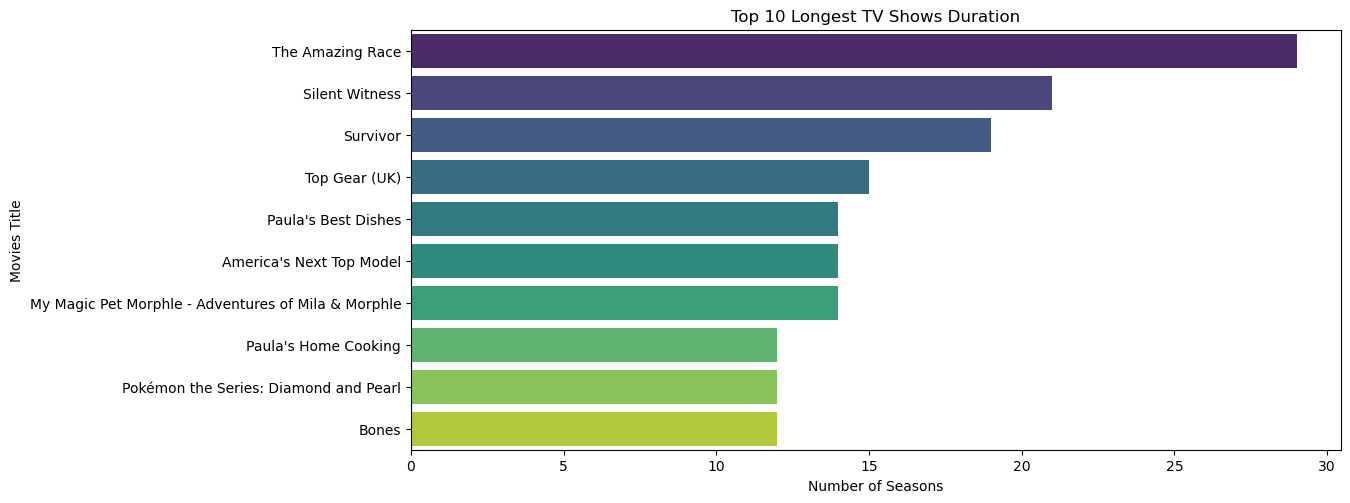

In [41]:
#plotting
plt.figure(figsize=(12,12))
#subplot 1: Top 10 longest Movies Duration
plt.subplot(2, 1, 2)
sns.barplot(data=df_tv_shows.sort_values(by="duration_num",
                                       ascending =False).head(10),y="title",x="duration_num",palette="viridis")
plt.title("Top 10 Longest TV Shows Duration")
plt.xlabel("Number of Seasons")
plt.ylabel("Movies Title")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_1468\1749397246.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_movies.sort_values(by="duration_num",
C:\Users\hp\AppData\Local\Temp\ipykernel_1468\1749397246.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_tv_shows.sort_values(by="duration_num",


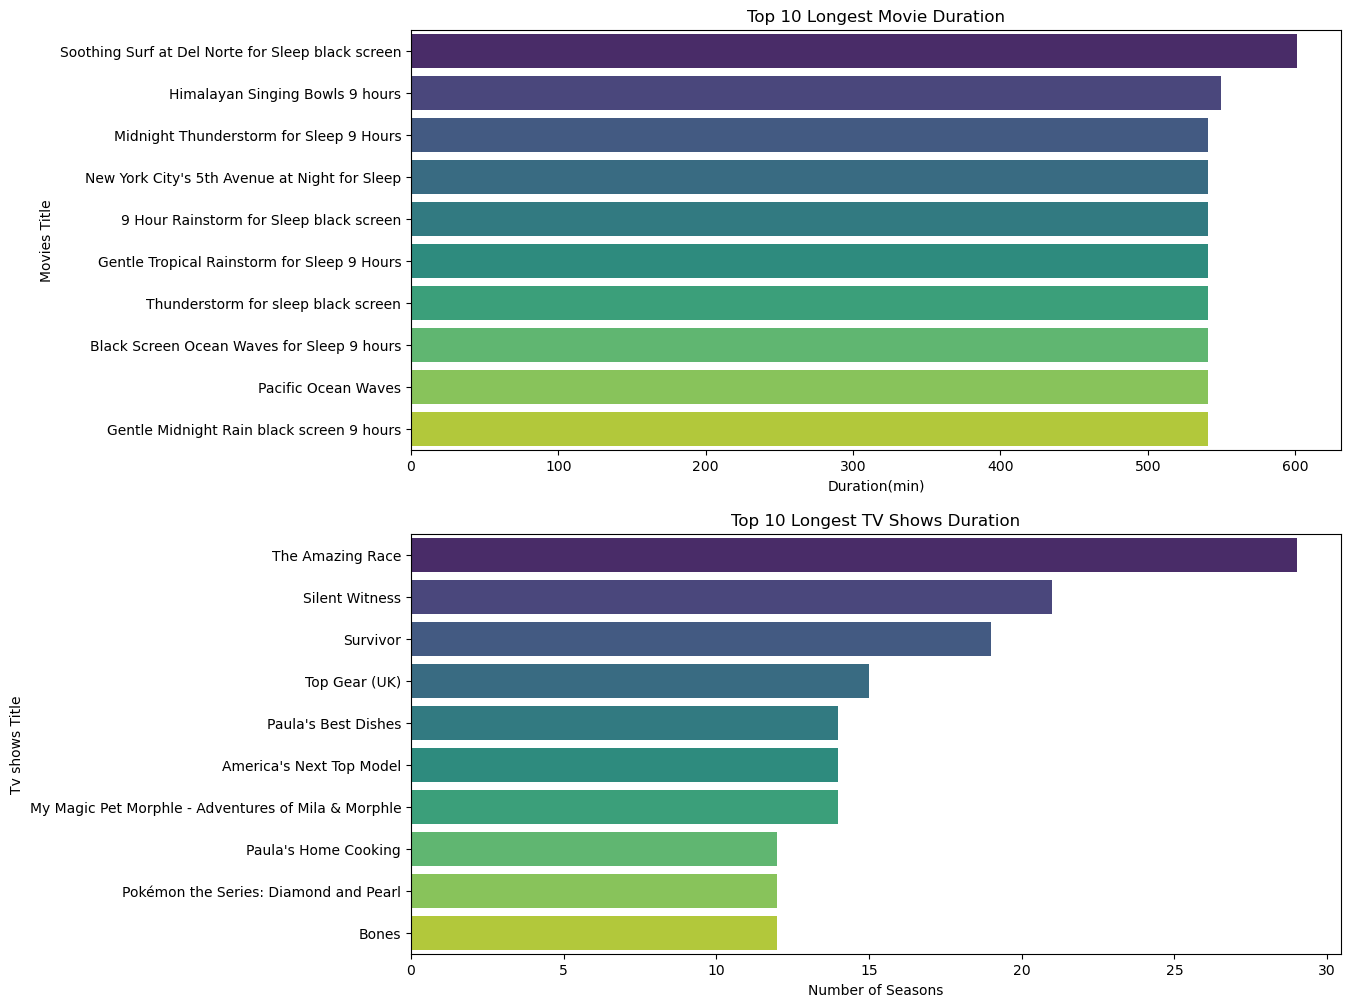

In [42]:
#plotting
plt.figure(figsize=(12,12))
#subplot 1: Top 10 longest Movies Duration
plt.subplot(2, 1, 1)
sns.barplot(data=df_movies.sort_values(by="duration_num",
                                       ascending =False).head(10),y="title",x="duration_num",palette="viridis")
plt.title("Top 10 Longest Movie Duration")
plt.xlabel("Duration(min)")
plt.ylabel("Movies Title")

#subplot 2: Top 10 longest TV Shows Duration
plt.subplot(2, 1, 2)
sns.barplot(data=df_tv_shows.sort_values(by="duration_num",
                                       ascending =False).head(10),y="title",x="duration_num",palette="viridis")
plt.title("Top 10 Longest TV Shows Duration")
plt.xlabel("Number of Seasons")
plt.ylabel("Tv shows Title")
plt.show()

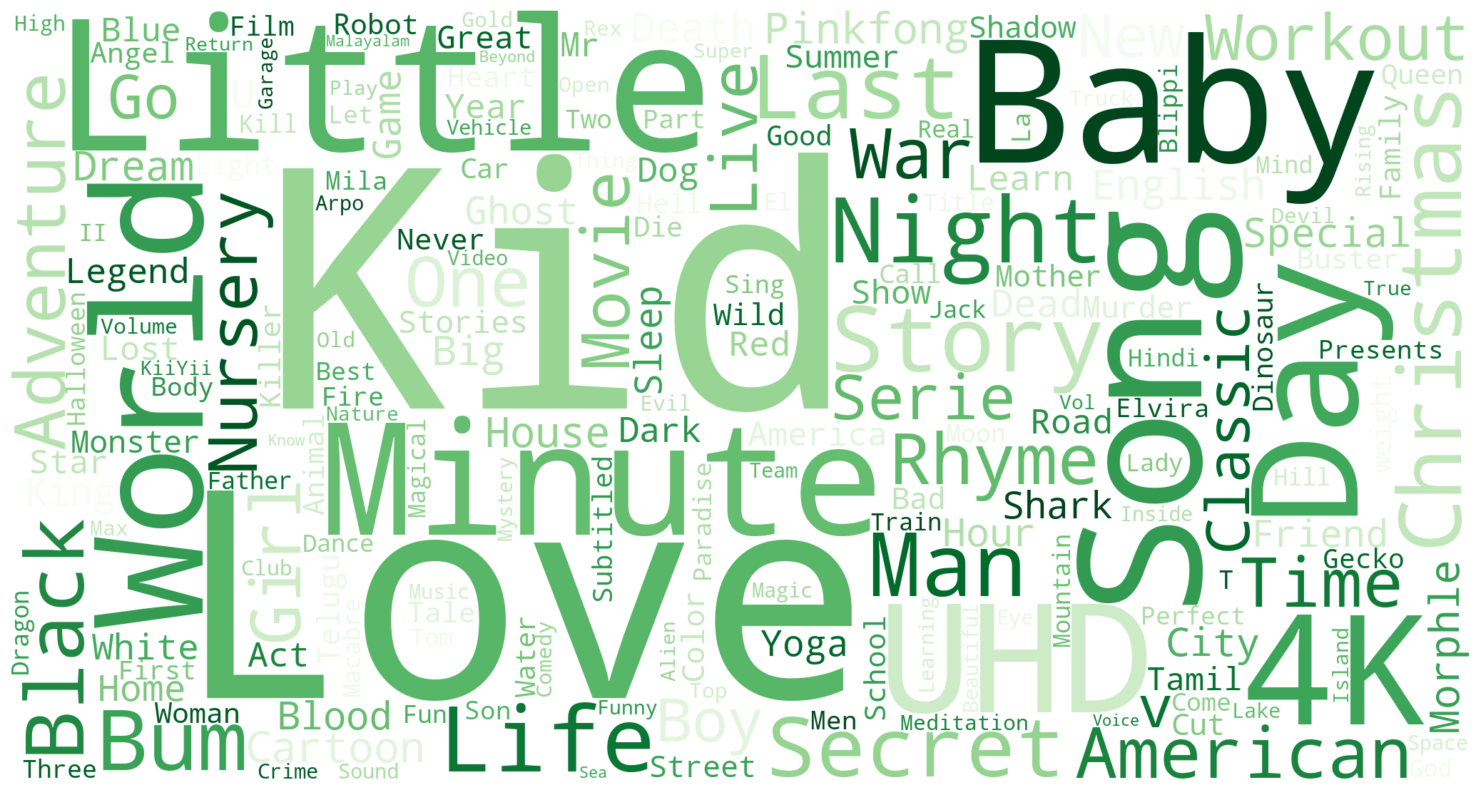

In [43]:
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator
txt1=" ".join(title for title in data.title)

word_cloud1=WordCloud(collocations=False,background_color="white",width=2048,height=1080,colormap="Greens_r").generate(txt1)

plt.figure(figsize=(30,10))
plt.imshow(word_cloud1,interpolation="bilinear")
plt.axis("off")
plt.show()

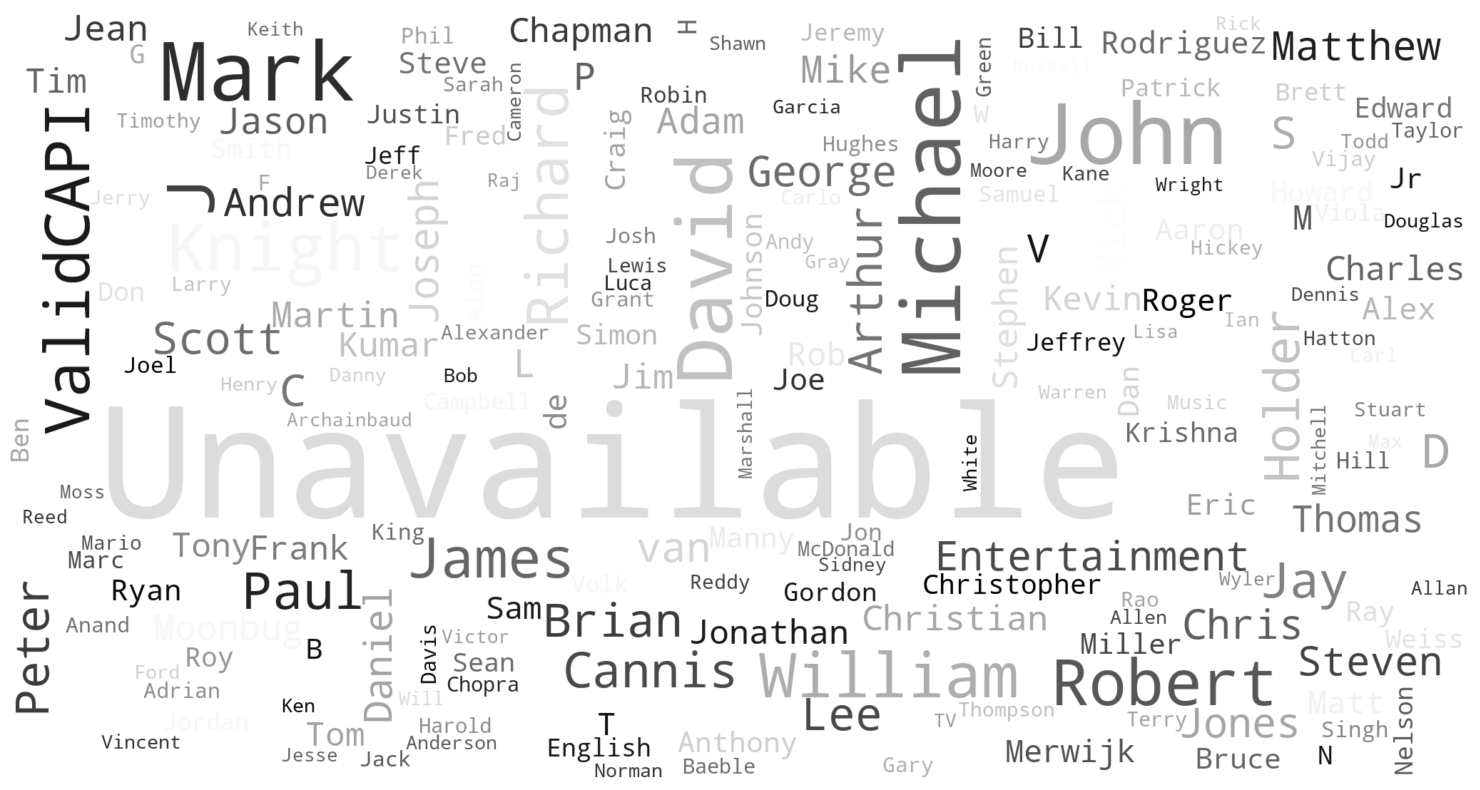

In [44]:
txt2=" ".join(director for director in data.director)

word_cloud2=WordCloud(collocations=False,background_color="white",width=2048,height=1080,colormap="gist_gray").generate(txt2)

plt.figure(figsize=(30,10))
plt.imshow(word_cloud2,interpolation="bilinear")
plt.axis("off")
plt.show()

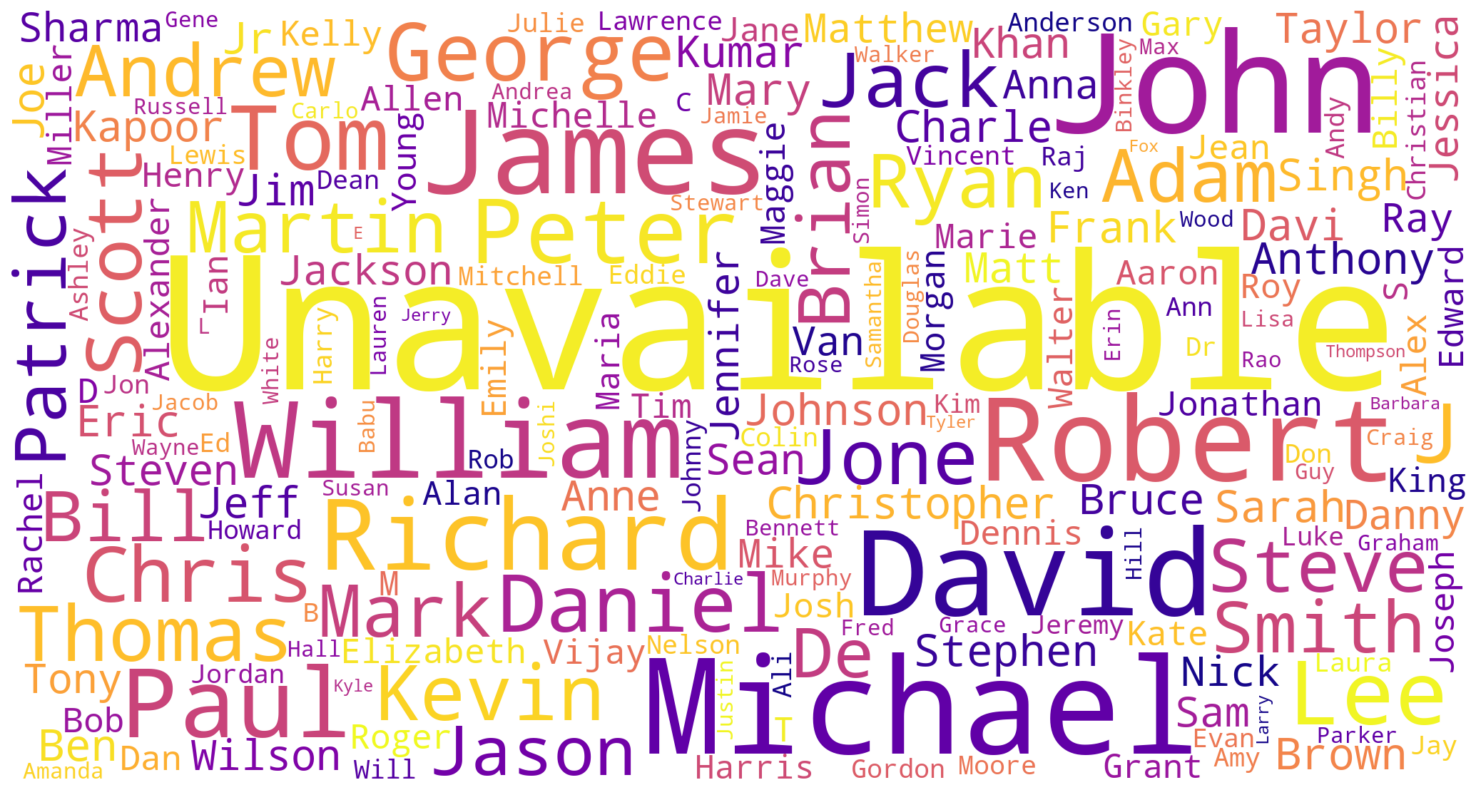

In [45]:
txt3=" ".join(cast for cast in data.cast)

word_cloud3=WordCloud(collocations=False,background_color="white",width=2048,height=1080,colormap="plasma").generate(txt3)

plt.figure(figsize=(30,10))
plt.imshow(word_cloud3,interpolation="bilinear")
plt.axis("off")
plt.show()